In [5]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('sci.mplstyle')

In [6]:
def RK4(a, b, N, alpha, phuongtrinh):
    h = (b - a) / N                  # tinh kich thuoc buoc thoi gian
    x = np.linspace(a, b, N + 1)     # tao mang thoi gian tu a den b gom N+1 diem
    y = np.zeros((N + 1, len(alpha)))# tao mang nghiem cho he ODE
    y[0] = alpha                     # gan dieu kien dau

    for i in range(N):               # lap qua tung buoc thoi gian
        k1 = phuongtrinh(x[i], y[i]) # dao ham tai dau buoc
        k2 = phuongtrinh(x[i] + h/2, y[i] + h*k1/2) # dao ham tai diem giua dung k1
        k3 = phuongtrinh(x[i] + h/2, y[i] + h*k2/2) # dao ham tai diem giua dung k2
        k4 = phuongtrinh(x[i] + h, y[i] + h*k3)     # dao ham tai cuoi buoc

        y[i+1] = y[i] + h*(k1 + 2*k2 + 2*k3 + k4)/6 # cap nhat nghiem RK4

    return x, y                      # tra ve mang thoi gian va nghiem

In [7]:
def phanra(t, Y):
    N_a = Y[0]   # So luong hat A
    N_b = Y[1]   # So luong hat B
    N_c = Y[2]   # So luong hat B
    global lambda_a, lambda_b


    dN_a_dt = -lambda_a * N_a
    dN_b_dt = lambda_a * N_a - lambda_b * N_b
    dN_c_dt = lambda_b * N_b
    F = np.array([dN_a_dt, dN_b_dt, dN_c_dt])
    return F

In [8]:
N_a_0 = 1.0
N_b_0 = 0.0
N_c_0 = 0.0

lambda_a = 1
lambda_b = 0.1

t_min = 0
t_max = 60
N_t = 5000

In [9]:
Y0_hatnhan = np.array([N_a_0, N_b_0, N_c_0])
t, Y_hatnhan = RK4(t_min, t_max, N_t, Y0_hatnhan, phanra)


In [10]:
def ghifile(t, Y_hatnhan, filename="hatnhan-RK4"):
    filename = f"KQ_{filename}.txt"

    with open(filename, "w", encoding="utf-8") as file:
        file.write("# Giai bai toan dong dien RK4\n")
        file.write("#\n")
        file.write(f"# {'t':>20s} {'N1':>20s} {'N2':>20s} {'N3':>20s}\n")

        for t_step in range(len(t)):
            file.write(f"  {t[t_step]:20.8e} {Y_hatnhan[t_step, 0]:20.8e} {Y_hatnhan[t_step, 1]:20.8e} {Y_hatnhan[t_step, 2]:20.8e}\n")

ghifile(t, Y_hatnhan, filename="hatnhan-RK4")

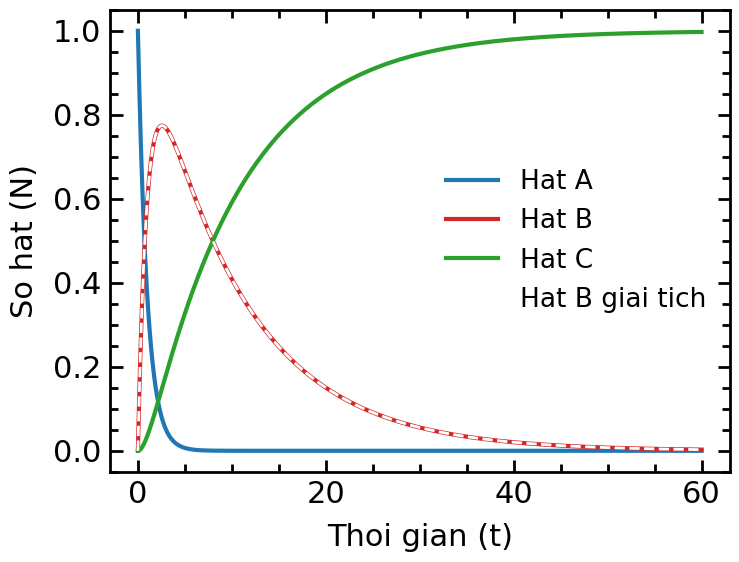

In [21]:
t_hatnhan, N1_hatnhan, N2_hatnhan, N3_hatnhan = np.loadtxt("KQ_hatnhan-RK4.txt", comments="#", unpack=True)


nghiem_giai_tich_B = lambda_a/(lambda_b - lambda_a) * (np.exp(-lambda_a*t_hatnhan) - np.exp(-lambda_b*t_hatnhan))

plt.figure(figsize=(8,6))
plt.plot(t_hatnhan, N1_hatnhan, color="C0", lw = 3, label = "Hat A")
plt.plot(t_hatnhan, N2_hatnhan, color="C1", lw = 3, label = "Hat B")
plt.plot(t_hatnhan, N3_hatnhan, color="C2", lw = 3, label = "Hat C")

plt.plot(t_hatnhan, nghiem_giai_tich_B, color="white", lw = 2, label = "Hat B giai tich", linestyle = '--')


plt.xlabel("Thoi gian (t)")
plt.ylabel("So hat (N)")
plt.legend()
plt.savefig("phanra.png", dpi = 300)


plt.show()

In [20]:
idx_max = np.argmax(N2_hatnhan) #Lay vi tri dat cuc dai

t_max = t_hatnhan[idx_max] #Doc gia tri tai N2 dat cuc dai
N2_max = N2_hatnhan[idx_max]

t_giai_tich = np.log(lambda_a/lambda_b)/(lambda_a - lambda_b)

print("t tại N2 cực đại =", t_max)
print("t tại N2 cực đại giai tich =", t_giai_tich)

print("N2 cực đại =", N2_max)



t tại N2 cực đại = 2.556
t tại N2 cực đại giai tich = 2.5584278811044956
N2 cực đại = 0.774263454
